# Urban Energy Analytics: NYC vs LA 2022

## Principal Component Analysis + Hierarchical Clustering of Residential Energy Consumption

**Team:**
- Atharva Prasanna Mokashi (SJSU ID: 019117046)
- Maitreya Patankar (SJSU ID: 019146166)
- Vineet Malewar (SJSU ID: 018399589)
- Shefali Saini (SJSU ID: 018281848)

---

## Overview

This notebook analyzes the relationship between socio-economic characteristics and residential electricity consumption across ZIP codes in NYC and LA using 2022 data from EIA Form 861 and ACS.

**Pipeline:**
1. Load EIA + ACS data
2. Clean and integrate datasets
3. Filter to NYC and LA
4. Engineer 5 modeling features
5. Apply PCA for dimensionality reduction
6. Perform hierarchical clustering
7. Evaluate and profile clusters
8. Compare NYC vs LA patterns

---

## Section 0: Setup and Imports

In [1]:
# If running in Google Colab, uncomment and run:
# from google.colab import drive
# drive.mount('/content/drive')
# !pip install -r requirements.txt

import sys
import os

# Add src to path for local imports
# Works from notebooks/ directory (Jupyter) or from repo root
_nb_dir = os.path.abspath(os.getcwd())
_repo_root = _nb_dir if os.path.isdir(os.path.join(_nb_dir, 'src')) else os.path.dirname(_nb_dir)
_src_path = os.path.join(_repo_root, 'src')
if _src_path not in sys.path:
    sys.path.insert(0, _src_path)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# Import custom modules
from data_loader import load_eia_data, load_acs_data
from data_cleaner import clean_and_integrate
from feature_engineering import engineer_features, get_feature_matrix
from modeling import standardize_features, apply_pca, apply_clustering, evaluate_clustering

# Setup plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All imports successful")

✓ All imports successful


---

## Section 1: Data Loading

In [2]:
# Load raw datasets
eia_raw = load_eia_data()
acs_raw = load_acs_data()

print("\n" + "="*60)
print("EIA Raw Data Head:")
print("="*60)
print(eia_raw.head())

print("\n" + "="*60)
print("ACS Raw Data Head:")
print("="*60)
print(acs_raw.head())

[EIA] Loaded 39,075 ZIP codes from eia861_sales_2022.csv
[EIA] Columns: ['ZIP', 'state', 'residential_mwh_sales', 'num_customers']
[EIA] Shape: (39075, 4)
[ACS] Loaded 29,996 ZCTAs from acs_zcta_2022.csv
[ACS] Columns: ['ZIP', 'population', 'median_income', 'median_year_structure_built', 'total_occupied_units', 'renter_occupied_units']
[ACS] Shape: (29996, 6)

EIA Raw Data Head:
     ZIP state  residential_mwh_sales  num_customers
0  00501    NY               22466.24           2456
1  00544    NY               22466.24           2456
2  01002    MA               10617.27           1555
3  01005    MA               10617.27           1555
4  01007    MA               10617.27           1555

ACS Raw Data Head:
     ZIP  population  median_income  median_year_structure_built  \
0  00601       16834        17526.0                       1980.0   
1  00602       37642        20260.0                       1978.0   
2  00603       49075        17703.0                       1980.0   
3  00606

---

## Section 2: Data Cleaning and Integration

In [3]:
# Run full data pipeline: clean, merge, filter
df_integrated = clean_and_integrate(eia_raw, acs_raw)

print("\n" + "="*60)
print("Integrated Dataset:")
print("="*60)
print(f"Shape: {df_integrated.shape}")
print(f"\nColumns: {df_integrated.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_integrated.head())

# Summary by city
print("\n" + "="*60)
print("Summary by City:")
print("="*60)
print(df_integrated.groupby('city')[['population', 'residential_mwh_sales', 'num_customers']].sum())

STEP 1: Clean EIA Data
[Clean EIA] After cleaning and aggregation: 39,075 unique ZIPs

STEP 2: Clean ACS Data
[Clean ACS] After cleaning: 29,996 ZCTAs retained

STEP 3: Merge EIA + ACS
[Merge] EIA ZIPs: 39,075, ACS ZCTAs: 29,996
[Merge] Inner join result: 28,692 merged rows
[Merge] Loss: 26.6% of EIA ZIPs (PO Box-only, non-ZCTA, etc.)

STEP 4: Filter to NYC + LA
[Filter] Extracted 476 ZIP codes for NYC and LA
  NYC: 185
  LA:  291

INTEGRATION COMPLETE

Integrated Dataset:
Shape: (476, 10)

Columns: ['ZIP', 'residential_mwh_sales', 'num_customers', 'state', 'population', 'median_income', 'median_year_structure_built', 'total_occupied_units', 'renter_occupied_units', 'city']

First few rows:
        ZIP  residential_mwh_sales  num_customers state  population  \
2193  10001               17799.76           3805    NY       27004   
2194  10002               17799.76           3805    NY       76518   
2195  10003               17799.76           3805    NY       53877   
2196  10004     

---

## Section 3: Exploratory Data Analysis (EDA)

In [4]:
# Basic statistics
print("Descriptive Statistics:")
print(df_integrated[['residential_mwh_sales', 'num_customers', 'population', 'median_income']].describe())

Descriptive Statistics:
       residential_mwh_sales  num_customers     population  median_income
count             476.000000     476.000000     476.000000     476.000000
mean            27102.601975    4654.575630   40547.165966   95349.981092
std             13329.295173    2022.508892   23509.868457   38353.638258
min             10004.510000    1649.000000     161.000000   24853.000000
25%             17799.760000    2822.000000   24857.500000   69255.750000
50%             18585.960000    3805.000000   36322.500000   88437.500000
75%             32726.550000    5344.000000   53332.750000  112365.000000
max             74452.950000   12297.000000  112750.000000  250001.000000


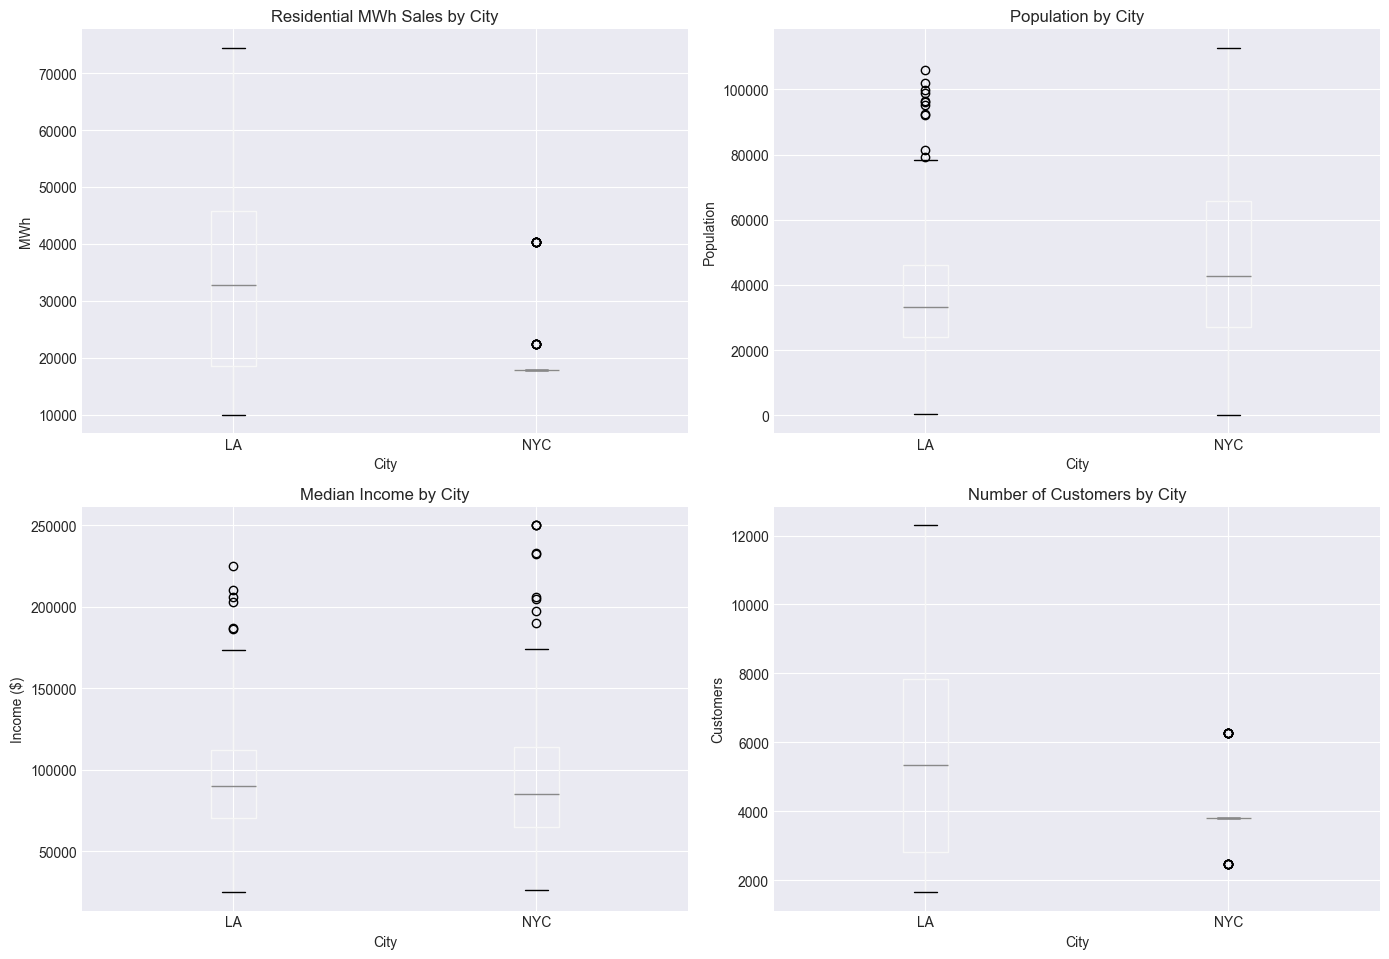

In [5]:
# Box plots by city
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_integrated.boxplot(column='residential_mwh_sales', by='city', ax=axes[0, 0])
axes[0, 0].set_title('Residential MWh Sales by City')
axes[0, 0].set_xlabel('City')
axes[0, 0].set_ylabel('MWh')

df_integrated.boxplot(column='population', by='city', ax=axes[0, 1])
axes[0, 1].set_title('Population by City')
axes[0, 1].set_xlabel('City')
axes[0, 1].set_ylabel('Population')

df_integrated.boxplot(column='median_income', by='city', ax=axes[1, 0])
axes[1, 0].set_title('Median Income by City')
axes[1, 0].set_xlabel('City')
axes[1, 0].set_ylabel('Income ($)')

df_integrated.boxplot(column='num_customers', by='city', ax=axes[1, 1])
axes[1, 1].set_title('Number of Customers by City')
axes[1, 1].set_xlabel('City')
axes[1, 1].set_ylabel('Customers')

plt.tight_layout()
plt.suptitle('')
plt.show()

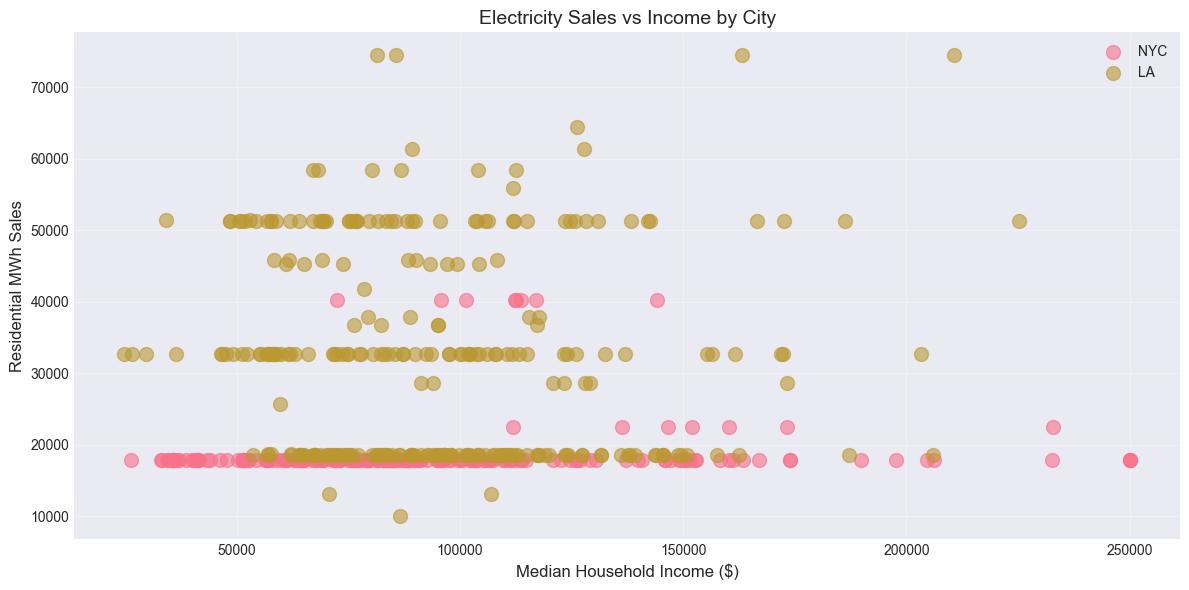

In [6]:
# Scatter plot: Electricity vs Income
fig, ax = plt.subplots(figsize=(12, 6))

for city in ['NYC', 'LA']:
    mask = df_integrated['city'] == city
    ax.scatter(
        df_integrated[mask]['median_income'],
        df_integrated[mask]['residential_mwh_sales'],
        label=city,
        alpha=0.6,
        s=100
    )

ax.set_xlabel('Median Household Income ($)', fontsize=12)
ax.set_ylabel('Residential MWh Sales', fontsize=12)
ax.set_title('Electricity Sales vs Income by City', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

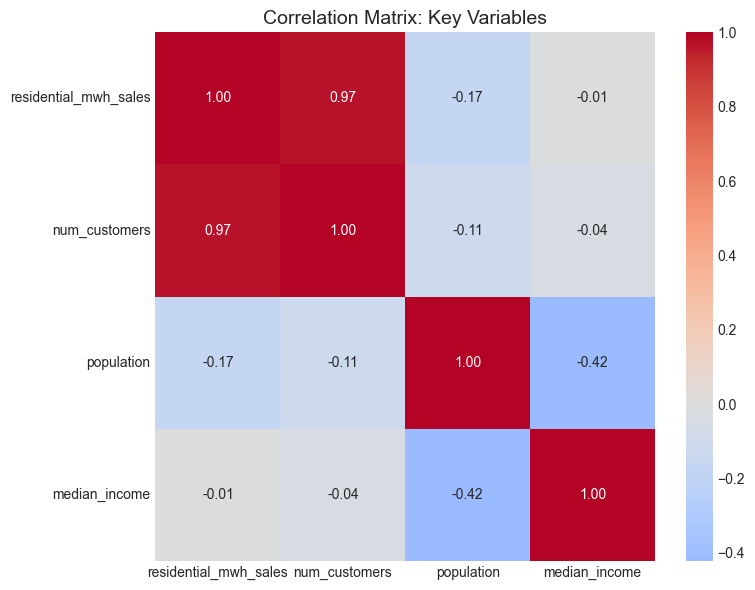

In [7]:
# Correlation heatmap
corr_cols = ['residential_mwh_sales', 'num_customers', 'population', 'median_income']
corr_matrix = df_integrated[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: Key Variables', fontsize=14)
plt.tight_layout()
plt.show()

---

## Section 4: Feature Engineering

In [8]:
# Engineer features
df_features = engineer_features(df_integrated)

print("\nDataset with engineered features:")
print(df_features.head())

[Features] Dropped 1 rows with invalid/missing features
[Features] Engineered 5 features for 475 ZIPs:
  - electricity_per_customer
  - electricity_per_capita
  - renter_occupancy_rate
  - housing_age
  - income_log

Feature Summary Statistics:
       electricity_per_customer  electricity_per_capita  \
count                475.000000              475.000000   
mean                   5.787014                1.486311   
std                    0.912029                4.274758   
min                    4.677992                0.157869   
25%                    4.677992                0.408393   
50%                    6.123980                0.657570   
75%                    6.586095                1.247281   
max                    9.147492               62.160401   

       renter_occupancy_rate  housing_age  income_log  
count             475.000000   475.000000  475.000000  
mean                0.546335    61.553684   11.386031  
std                 0.223447    14.534215    0.394602  

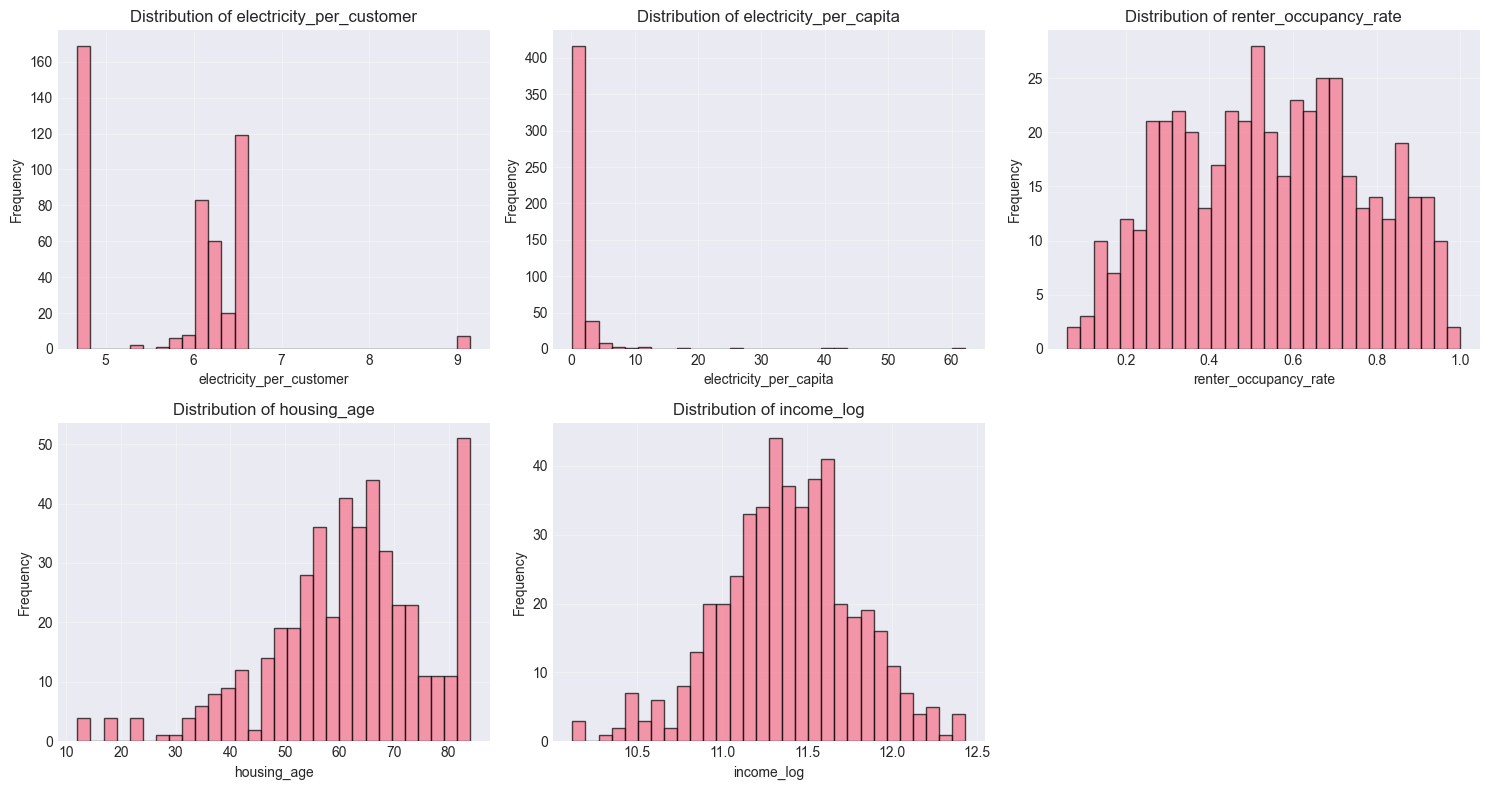

In [9]:
# Feature histograms
feature_cols = [
    'electricity_per_customer',
    'electricity_per_capita',
    'renter_occupancy_rate',
    'housing_age',
    'income_log'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df_features[col], bins=30, alpha=0.7, edgecolor='black')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].grid(True, alpha=0.3)

# Hide empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

---

## Section 5: PCA Analysis

In [10]:
# Get feature matrix
feature_matrix = get_feature_matrix(df_features)

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Columns: {feature_matrix.columns.tolist()}")

Feature matrix shape: (475, 5)
Columns: ['electricity_per_customer', 'electricity_per_capita', 'renter_occupancy_rate', 'housing_age', 'income_log']


In [11]:
# Standardize features
scaler, std_features = standardize_features(feature_matrix)
print(f"Standardized features shape: {std_features.shape}")

[Standardize] Standardized 5 features for 475 ZIPs
Standardized features shape: (475, 5)


In [12]:
# Apply PCA
pca_data = apply_pca(std_features, variance_threshold=0.85)

print(f"\nPCA Results:")
print(f"Number of components: {pca_data['n_components']}")
print(f"Explained variance ratio: {pca_data['explained_variance_ratio']}")
print(f"Cumulative variance: {pca_data['cumulative_variance']}")

[PCA] Selected 4 components explaining 93.03% variance
[PCA] Explained variance per component: [0.40247779 0.19488106 0.18304054 0.14987354]

PCA Results:
Number of components: 4
Explained variance ratio: [0.40247779 0.19488106 0.18304054 0.14987354]
Cumulative variance: [0.40247779 0.59735886 0.7803994  0.93027294]


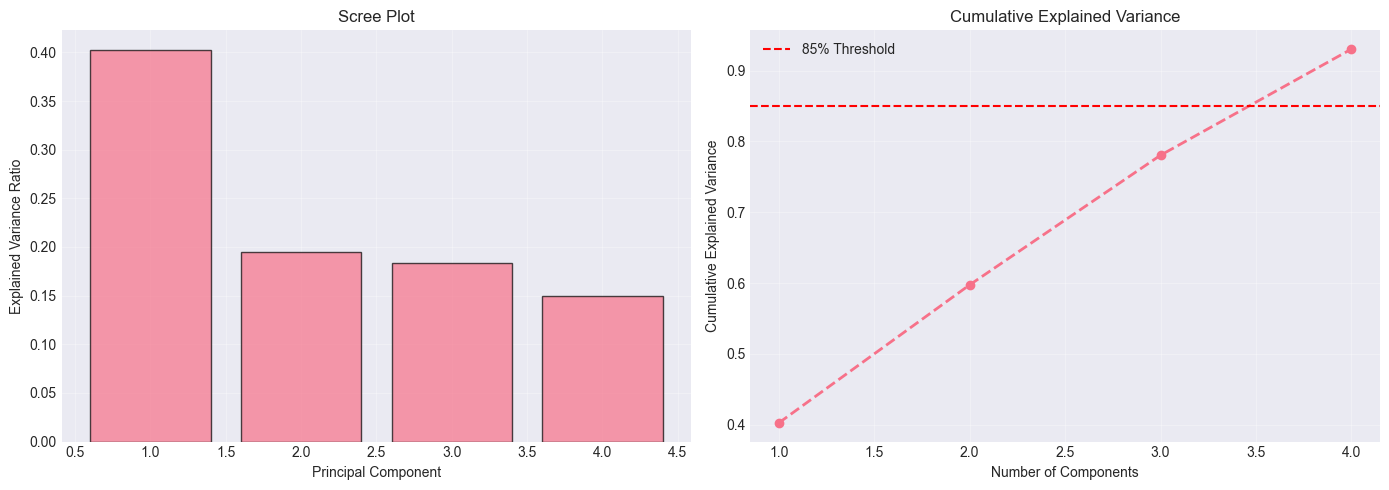

In [13]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_data['explained_variance_ratio']) + 1),
             pca_data['explained_variance_ratio'],
             alpha=0.7,
             edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, len(pca_data['cumulative_variance']) + 1),
              pca_data['cumulative_variance'],
              marker='o',
              linestyle='--',
              linewidth=2)
axes[1].axhline(y=0.85, color='r', linestyle='--', label='85% Threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Section 6: Hierarchical Clustering

In [14]:
# Apply clustering
clustering_data = apply_clustering(pca_data, k_min=2, k_max=7)

print(f"\nClustering Results:")
print(f"Optimal k: {clustering_data['optimal_k']}")
print(f"Best silhouette score: {clustering_data['best_silhouette']:.4f}")
print(f"\nSilhouette scores for each k:")
for k, score in sorted(clustering_data['silhouette_scores'].items()):
    print(f"  k={k}: {score:.4f}")

[Clustering] k=2: silhouette score = 0.2576
[Clustering] k=3: silhouette score = 0.2464
[Clustering] k=4: silhouette score = 0.2545
[Clustering] k=5: silhouette score = 0.2675
[Clustering] k=6: silhouette score = 0.2697


[Clustering] k=7: silhouette score = 0.2598
[Clustering] Optimal k = 6 with silhouette score = 0.2697

Clustering Results:
Optimal k: 6
Best silhouette score: 0.2697

Silhouette scores for each k:
  k=2: 0.2576
  k=3: 0.2464
  k=4: 0.2545
  k=5: 0.2675
  k=6: 0.2697
  k=7: 0.2598


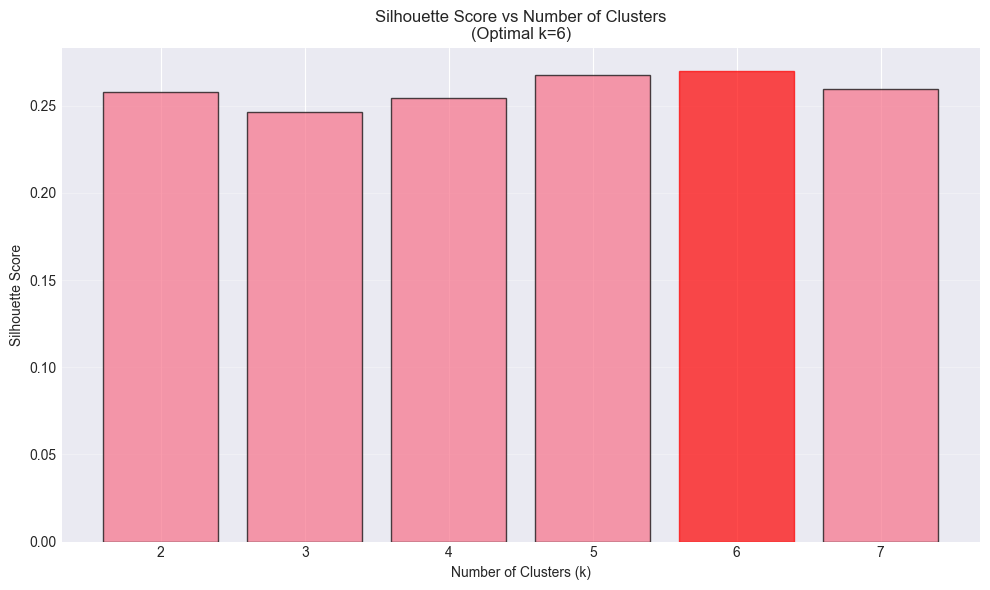

In [15]:
# Visualize silhouette scores
fig, ax = plt.subplots(figsize=(10, 6))

k_values = sorted(clustering_data['silhouette_scores'].keys())
scores = [clustering_data['silhouette_scores'][k] for k in k_values]

bars = ax.bar(k_values, scores, alpha=0.7, edgecolor='black')

# Highlight optimal k
optimal_idx = k_values.index(clustering_data['optimal_k'])
bars[optimal_idx].set_color('red')

ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title(f'Silhouette Score vs Number of Clusters\n(Optimal k={clustering_data["optimal_k"]})')
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

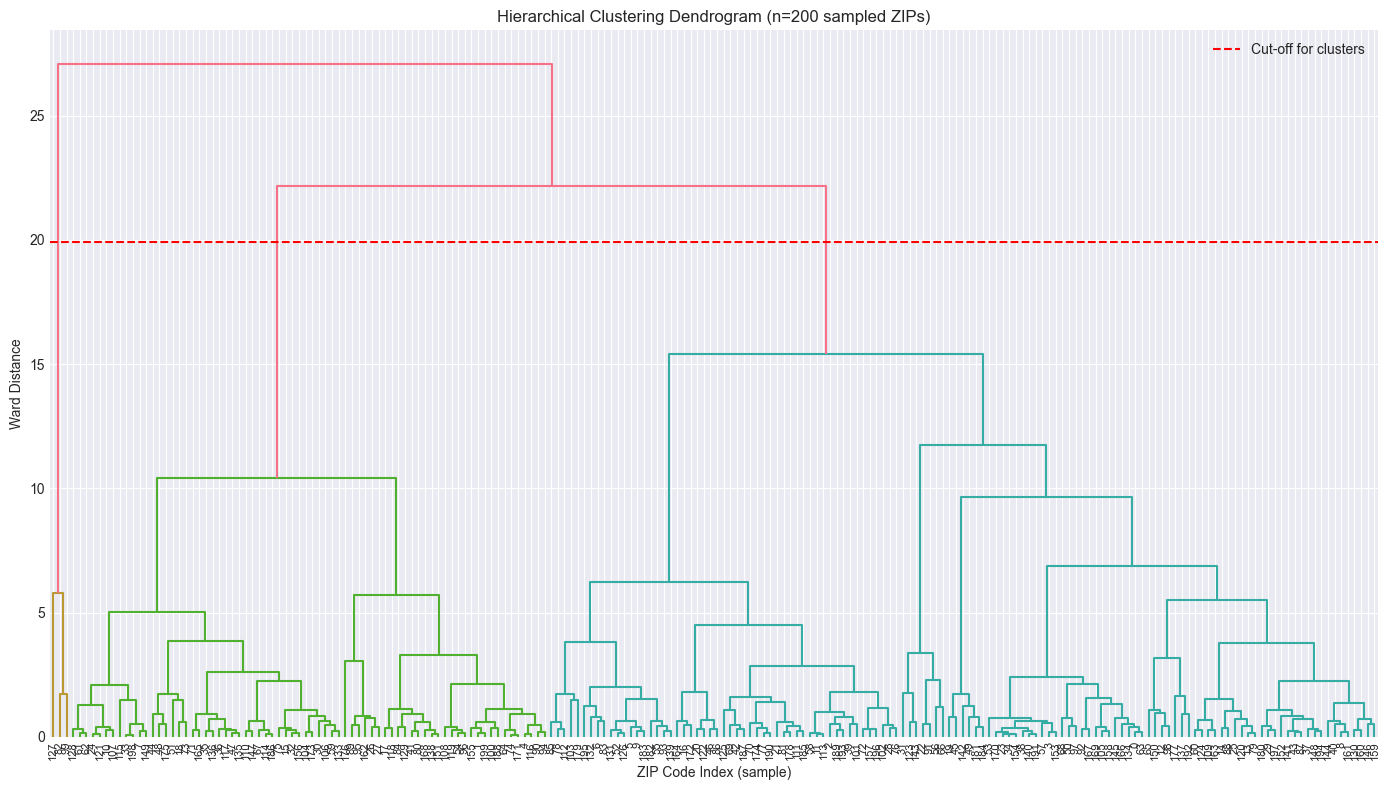

In [16]:
# Dendrogram (on subsample for clarity)
# Sample 200 ZIPs for dendrogram to avoid clutter
sample_size = min(200, len(pca_data['transformed']))
sample_idx = np.random.choice(len(pca_data['transformed']), sample_size, replace=False)
sample_features = pca_data['transformed'][sample_idx]

# Compute linkage
Z = linkage(sample_features, method='ward')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(14, 8))

dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=8)
ax.set_xlabel('ZIP Code Index (sample)')
ax.set_ylabel('Ward Distance')
ax.set_title(f'Hierarchical Clustering Dendrogram (n={sample_size} sampled ZIPs)')
ax.axhline(y=ax.get_ylim()[1] * 0.7, color='r', linestyle='--', label='Cut-off for clusters')
ax.legend()

plt.tight_layout()
plt.show()

---

## Section 7: Cluster Profiling and NYC vs LA Comparison

In [17]:
# Evaluate clustering: adds cluster labels to df_features, computes profiles
eval_data = evaluate_clustering(df_features, pca_data, clustering_data)

# Convenience reference used by cells below
df_clustered = eval_data['df_clustered']

# Cluster sizes
print("\nCluster Sizes:")
print(df_clustered['cluster'].value_counts().sort_index())


[Evaluation] Cluster Profiles (means):
         electricity_per_customer  electricity_per_capita  \
cluster                                                     
0                        6.532289                1.493578   
1                        4.936827                0.806131   
2                        6.586095               42.398809   
3                        4.804310                1.416959   
4                        6.277701                1.089647   
5                        4.687446                0.701562   

         renter_occupancy_rate  housing_age  income_log  median_income  
cluster                                                                 
0                     0.327777    56.358108   11.657276  119125.479730  
1                     0.817795    70.916667   10.890748   56274.988095  
2                     0.274768    60.000000   11.772686  131307.250000  
3                     0.606203    44.947368   11.764257  134303.842105  
4                     0.624699   

In [18]:
# NYC vs LA distribution
print("\nCluster Distribution by City:")
print(eval_data['city_distribution'])


Cluster Distribution by City:
city      LA  NYC  All
cluster               
0        132   16  148
1         15   69   84
2          4    0    4
3          3   35   38
4        136    0  136
5          1   64   65
All      291  184  475


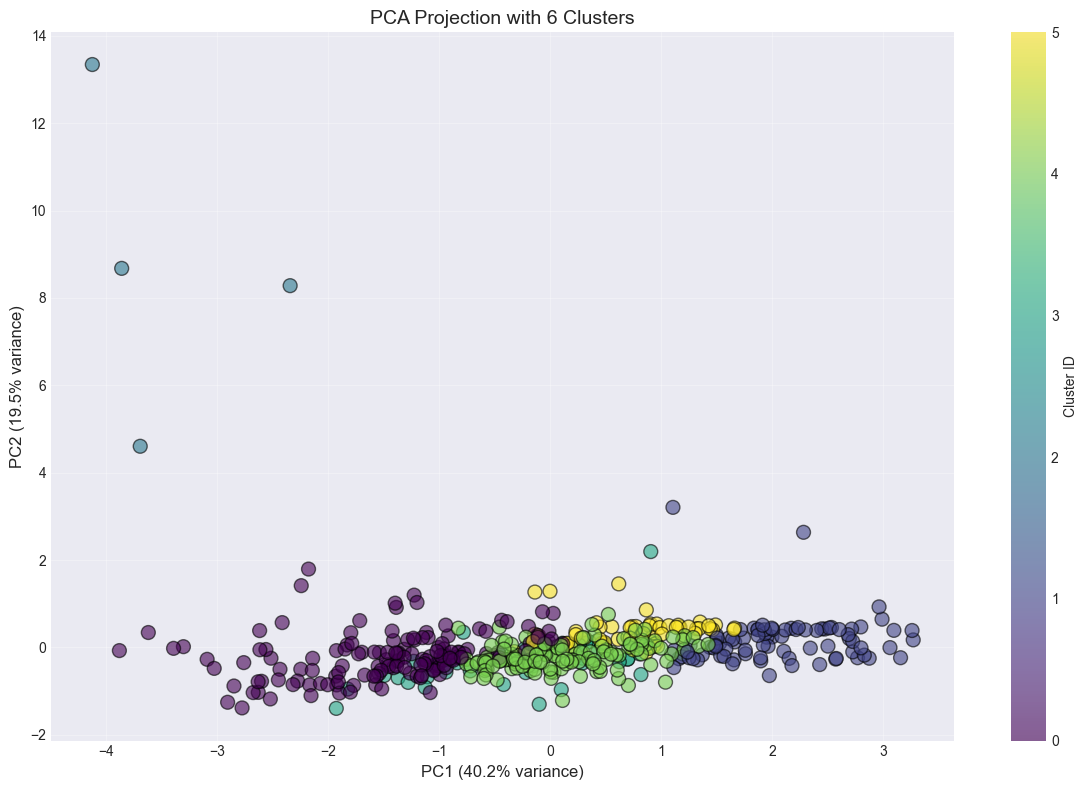

In [19]:
# Visualize clusters: PCA plot
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    pca_data['transformed'][:, 0],
    pca_data['transformed'][:, 1] if pca_data['n_components'] > 1 else np.zeros(len(pca_data['transformed'])),
    c=clustering_data['labels'],
    cmap='viridis',
    s=100,
    alpha=0.6,
    edgecolors='black'
)

ax.set_xlabel(f'PC1 ({pca_data["explained_variance_ratio"][0]:.1%} variance)', fontsize=12)
if pca_data['n_components'] > 1:
    ax.set_ylabel(f'PC2 ({pca_data["explained_variance_ratio"][1]:.1%} variance)', fontsize=12)
else:
    ax.set_ylabel('Dummy axis', fontsize=12)

ax.set_title(f'PCA Projection with {clustering_data["optimal_k"]} Clusters', fontsize=14)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster ID')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

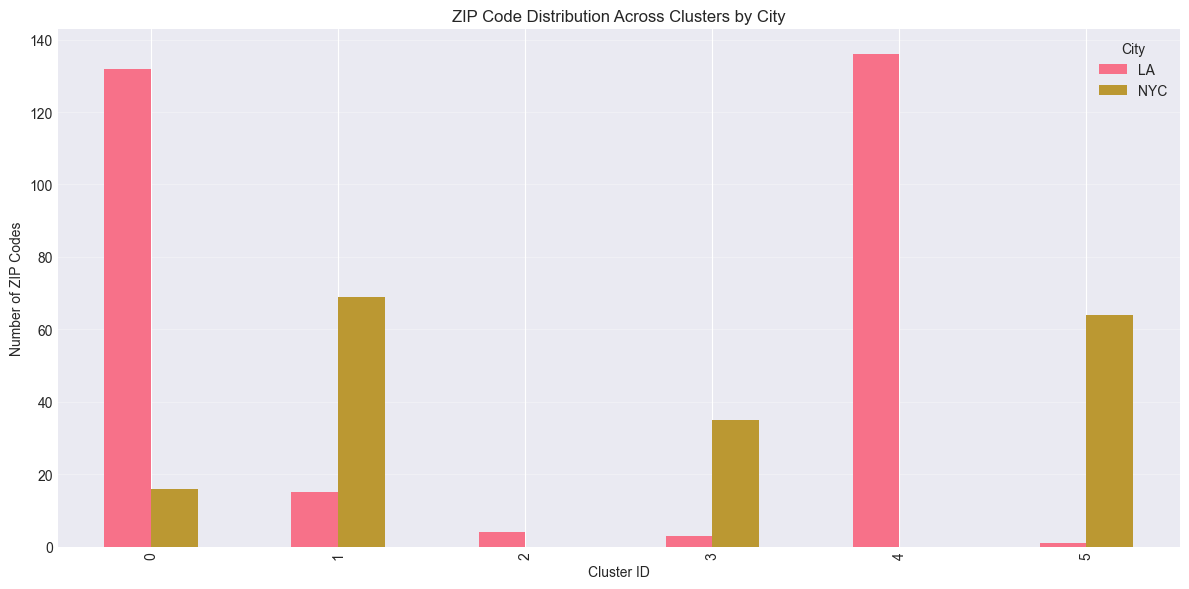

In [20]:
# NYC vs LA cluster comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Count ZIPs per cluster by city
cluster_city_counts = pd.crosstab(df_clustered['cluster'], df_clustered['city'])

cluster_city_counts.plot(kind='bar', ax=ax)
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Number of ZIP Codes')
ax.set_title('ZIP Code Distribution Across Clusters by City')
ax.legend(title='City')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [21]:
# Summary statistics by cluster
print("\n" + "="*80)
print("CLUSTER SUMMARY STATISTICS")
print("="*80)

summary_cols = ['electricity_per_customer', 'electricity_per_capita', 'median_income', 'population']

for cluster_id in sorted(df_clustered['cluster'].unique()):
    cluster_data = df_clustered[df_clustered['cluster'] == cluster_id]
    n_zips = len(cluster_data)
    n_nyc = len(cluster_data[cluster_data['city'] == 'NYC'])
    n_la = len(cluster_data[cluster_data['city'] == 'LA'])
    
    print(f"\nCluster {cluster_id}: {n_zips} ZIPs ({n_nyc} NYC, {n_la} LA)")
    print("-" * 80)
    print(cluster_data[summary_cols].describe().loc[['mean', 'std']].round(2))


CLUSTER SUMMARY STATISTICS

Cluster 0: 148 ZIPs (16 NYC, 132 LA)
--------------------------------------------------------------------------------
      electricity_per_customer  electricity_per_capita  median_income  \
mean                      6.53                    1.49      119125.48   
std                       0.63                    1.71       31163.17   

      population  
mean    32304.89  
std     17812.92  

Cluster 1: 84 ZIPs (69 NYC, 15 LA)
--------------------------------------------------------------------------------
      electricity_per_customer  electricity_per_capita  median_income  \
mean                      4.94                    0.81       56274.99   
std                       0.56                    2.21       16939.43   

      population  
mean    59081.37  
std     26016.53  

Cluster 2: 4 ZIPs (0 NYC, 4 LA)
--------------------------------------------------------------------------------
      electricity_per_customer  electricity_per_capita  median_incom

---

## Conclusion

This analysis applied Principal Component Analysis followed by hierarchical clustering to identify distinct energy consumption patterns across NYC and LA ZIP codes. The results reveal neighborhood energy profiles that reflect underlying socio-economic characteristics such as income, housing age, and renter occupancy rates.